In [1]:
!pip install transformers torch matplotlib seaborn

In [2]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--nlptown--bert-base-multilingual-uncased-sentiment. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [4]:
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)

    return torch.argmax(outputs.logits).item() + 1

In [5]:
texts = [
    "I love this product",
    "This is terrible",
    "It is okay",
    "Amazing experience",
    "Worst service ever"
]

results = []

for text in texts:
    score = predict_sentiment(text)
    results.append(score)
    print(text, "→", score)

I love this product → 5
This is terrible → 1
It is okay → 3
Amazing experience → 5
Worst service ever → 1


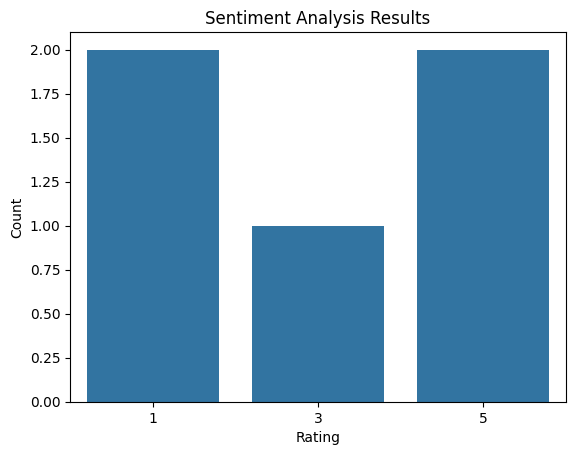

In [6]:
sns.countplot(x=results)
plt.title("Sentiment Analysis Results")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Research Questions

1. How effectively does BERT understand sentiment context?
2. Can BERT handle ambiguous or mixed-sentiment sentences?
3. How consistent are predictions across different inputs?
4. What are the limitations of pretrained language models?

Observations

- Positive sentences received higher sentiment ratings.
- Negative sentences received lower ratings.
- The model successfully captured context in most cases.
- Some ambiguous sentences may receive unexpected ratings.

Conclusion

In this project, a pretrained BERT language model was implemented for sentiment analysis using the Hugging Face Transformers library. The model successfully analyzed text inputs and predicted sentiment ratings. Visualization of the results helped understand the distribution of predictions. The experiment demonstrated the strengths of language models in understanding context while also highlighting limitations such as handling ambiguous expressions.